In [44]:
import networkx as nx
import matplotlib.pyplot as plt
import random
import numpy as np
import pandas as pd
import ast

In [45]:
df_edges

,Label,Aquaintance,Friend,Study,Support,Politics,OldFriend,Grade,LeftRight,Group
0,70l,[s44],[],[s44],[s44],[],[],"[('s44', 7.0)]","[('s44', 6.0)]","[('s44', 1.0)]"
1,s44,[70l],[70l],[],[],[],[],"[('70l', 7.0)]","[('70l', 4.0)]","[('70l', 1.0)]"
2,467,"[199, ym6, e8i, f7n, o2r]","[199, f7n]","[199, ym6, o2r]",[],[e8i],[],"[('199', 4.0), ('ym6', 2.0), ('e8i', 5.0), ('f...","[('199', 2.0), ('ym6', 3.0), ('e8i', 3.0), ('f...","[('199', 1.0), ('ym6', 2.0), ('e8i', 2.0), ('f..."
3,cav,"[0fo, yyj, hro, wom, rji, zfv, 7mf, 3rt, i9d]","[0fo, yyj, hro, wom, rji, zfv, 7mf, 3rt, i9d]",[],"[0fo, yyj, hro, wom, rji, zfv, 7mf, 3rt, i9d]",[],[],"[('0fo', 1.0), ('yyj', 1.0), ('hro', 1.0), ('w...","[('0fo', 6.0), ('yyj', 6.0), ('hro', 6.0), ('w...","[('0fo', 1.0), ('yyj', 1.0), ('hro', 1.0), ('w..."
4,6nj,"[cos, ats, epz]","[cos, ats, epz]",[cos],"[cos, ats]",[],"['cos', 'ats']","[('cos', 4.0), ('ats', 3.0), ('epz', 4.0)]","[('cos', 4.0), ('ats', 3.0), ('epz', 2.0)]","[('cos', 1.0), ('ats', 1.0), ('epz', 1.0)]"
...,...,...,...,...,...,...,...,...,...,...
247,gd8,[],[],[],[],[],[],[],[],[]
248,oi6,[],[],[],[],[],[],[],[],[]
249,k3y,"[99v, muh, 2fc, 0fo]","[99v, 0fo]",[],"[muh, 2fc]",[],[],"[('99v', 0.0), ('muh', 0.0), ('2fc', 0.0), ('0...","[('99v', 1.0), ('muh', 0.0), ('2fc', 0.0), ('0...","[('99v', 4.0), ('muh', 3.0), ('2fc', 2.0), ('0..."
250,1ds,"[8bz, g8f, mjb, 1k3, qoh, pgw]","[8bz, g8f, mjb, 1k3, qoh, pgw]","[g8f, 1k3, pgw]",[],"[g8f, 1k3]",[],"[('8bz', 0.0), ('g8f', 0.0), ('mjb', 0.0), ('1...","[('8bz', 5.0), ('g8f', 3.0), ('mjb', 4.0), ('1...","[('8bz', 1.0), ('g8f', 1.0), ('mjb', 1.0), ('1..."


In [46]:
df_edges = pd.read_csv('data_edges.csv')

df_edges["Friend"] = df_edges["Friend"].apply(ast.literal_eval)
df_edges["Aquaintance"] = df_edges["Aquaintance"].apply(ast.literal_eval)
df_edges["Study"] = df_edges["Study"].apply(ast.literal_eval)
df_edges["Politics"] = df_edges["Politics"].apply(ast.literal_eval)
df_edges["Support"] = df_edges["Support"].apply(ast.literal_eval)

columns = ["Aquaintance", "Friend", "Study", "Poltics", "Support"]

def network_loom(column):
    edge_list = []
    for index, row in df_edges.iterrows():
        source = row['Label']

        for target in row[column]:
            edge_list.append((source, target))

    G = nx.DiGraph()
    G.add_edges_from(edge_list)
    G.remove_edges_from(nx.selfloop_edges(G))

    return G

G_aquaintance = network_loom("Aquaintance")
G_friend = network_loom("Friend")
G_poltics = network_loom("Study")
G_study = network_loom("Politics")
G_support = network_loom("Support")



In [47]:
nx.reciprocity(G_study)

0.36018957345971564

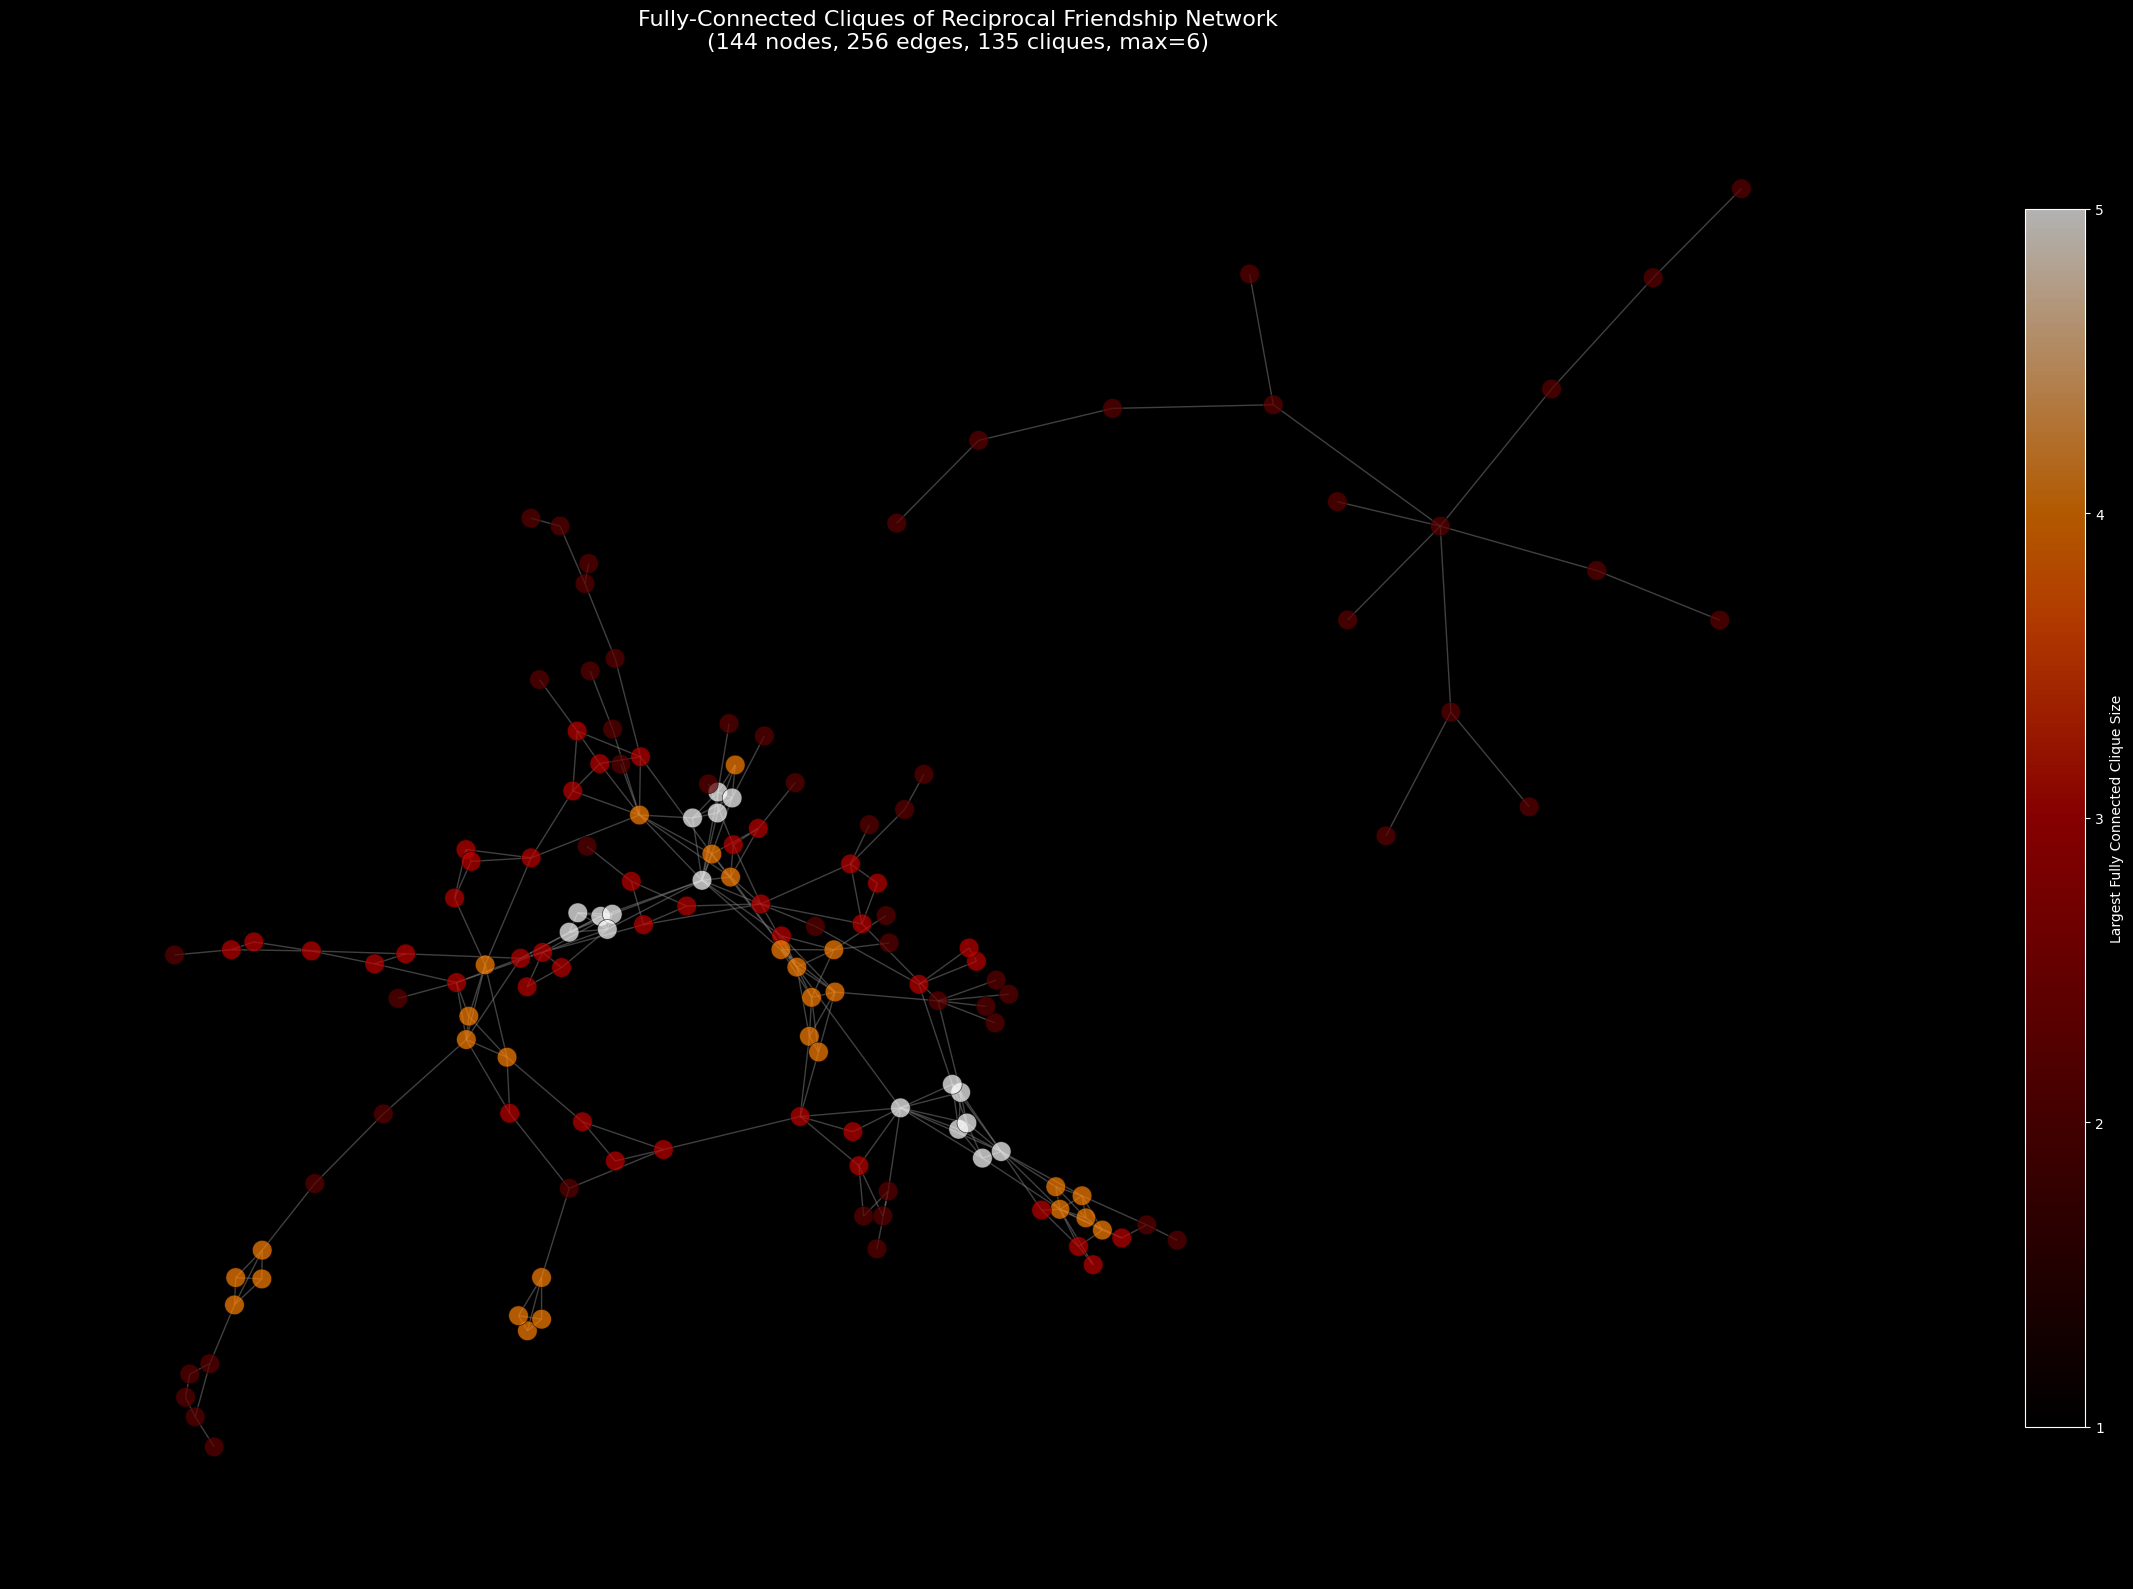


Clique analysis:
Total maximal cliques: 135
Largest clique size: 6
Average clique size: 2.59
Color scale: 1 to 5


In [48]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

# -----------------------------
# FIXED COLOR SCALE
# -----------------------------
CLIQUE_MIN = 1  # Minimum clique size for color scale
CLIQUE_MAX = 5  # Maximum clique size for color scale
# Adjust CLIQUE_MAX based on your domain knowledge

# Convert to undirected (reciprocal edges only)
G_undirected = G_support.to_undirected(reciprocal=False)

# Filter isolated nodes (optional - uncomment if needed)
isolated_nodes = list(nx.isolates(G_undirected))
G_undirected.remove_nodes_from(isolated_nodes)

components = sorted(nx.connected_components(G_undirected), key=len, reverse=True)
two_largest = components[0] | components[1]  # Union of the two sets

# Create subgraph with both components
G_undirected = G_undirected.subgraph(two_largest).copy()


G_sub = G_undirected.copy()

# Find cliques and calculate node colors
cliques = list(nx.find_cliques(G_sub))
clique_sizes = {}
for node in G_sub.nodes():
    max_size = 0
    for clique in cliques:
        if node in clique:
            max_size = max(max_size, len(clique))
    clique_sizes[node] = max_size

node_colors = [clique_sizes[node] for node in G_sub.nodes()]

# Create figure
plt.figure(figsize=(24, 16))

# Generate layout
from networkx.drawing.nx_agraph import graphviz_layout
pos = graphviz_layout(G_sub, prog='sfdp')

# Draw nodes with FIXED colormap scale
nodes = nx.draw_networkx_nodes(G_sub, pos, node_size=200, 
                                node_color=node_colors, 
                                cmap='gist_heat', alpha=0.7, 
                                linewidths=0.5, edgecolors='black',
                                vmin=CLIQUE_MIN, vmax=CLIQUE_MAX)  # <-- FIXED SCALE

# Draw edges
nx.draw_networkx_edges(G_sub, pos, edge_color='gray', 
                       alpha=0.5, width=1)

# Add colorbar with fixed scale
cbar = plt.colorbar(nodes, label='Largest Fully Connected Clique Size', shrink=0.8)
cbar.set_ticks(range(CLIQUE_MIN, CLIQUE_MAX + 1))

# Title
actual_max = max(node_colors) if node_colors else 0
plt.style.use('dark_background')
plt.title(f"Fully-Connected Cliques of Reciprocal Friendship Network\n"
          f"({len(G_sub.nodes())} nodes, {len(G_sub.edges())} edges, "
          f"{len(cliques)} cliques, max={actual_max})", 
          fontsize=16)
plt.axis('off')
plt.tight_layout()
plt.show()

# Print clique information
print(f"\nClique analysis:")
print(f"Total maximal cliques: {len(cliques)}")
clique_sizes_list = [len(c) for c in cliques]
print(f"Largest clique size: {max(clique_sizes_list)}")
print(f"Average clique size: {np.mean(clique_sizes_list):.2f}")
print(f"Color scale: {CLIQUE_MIN} to {CLIQUE_MAX}")

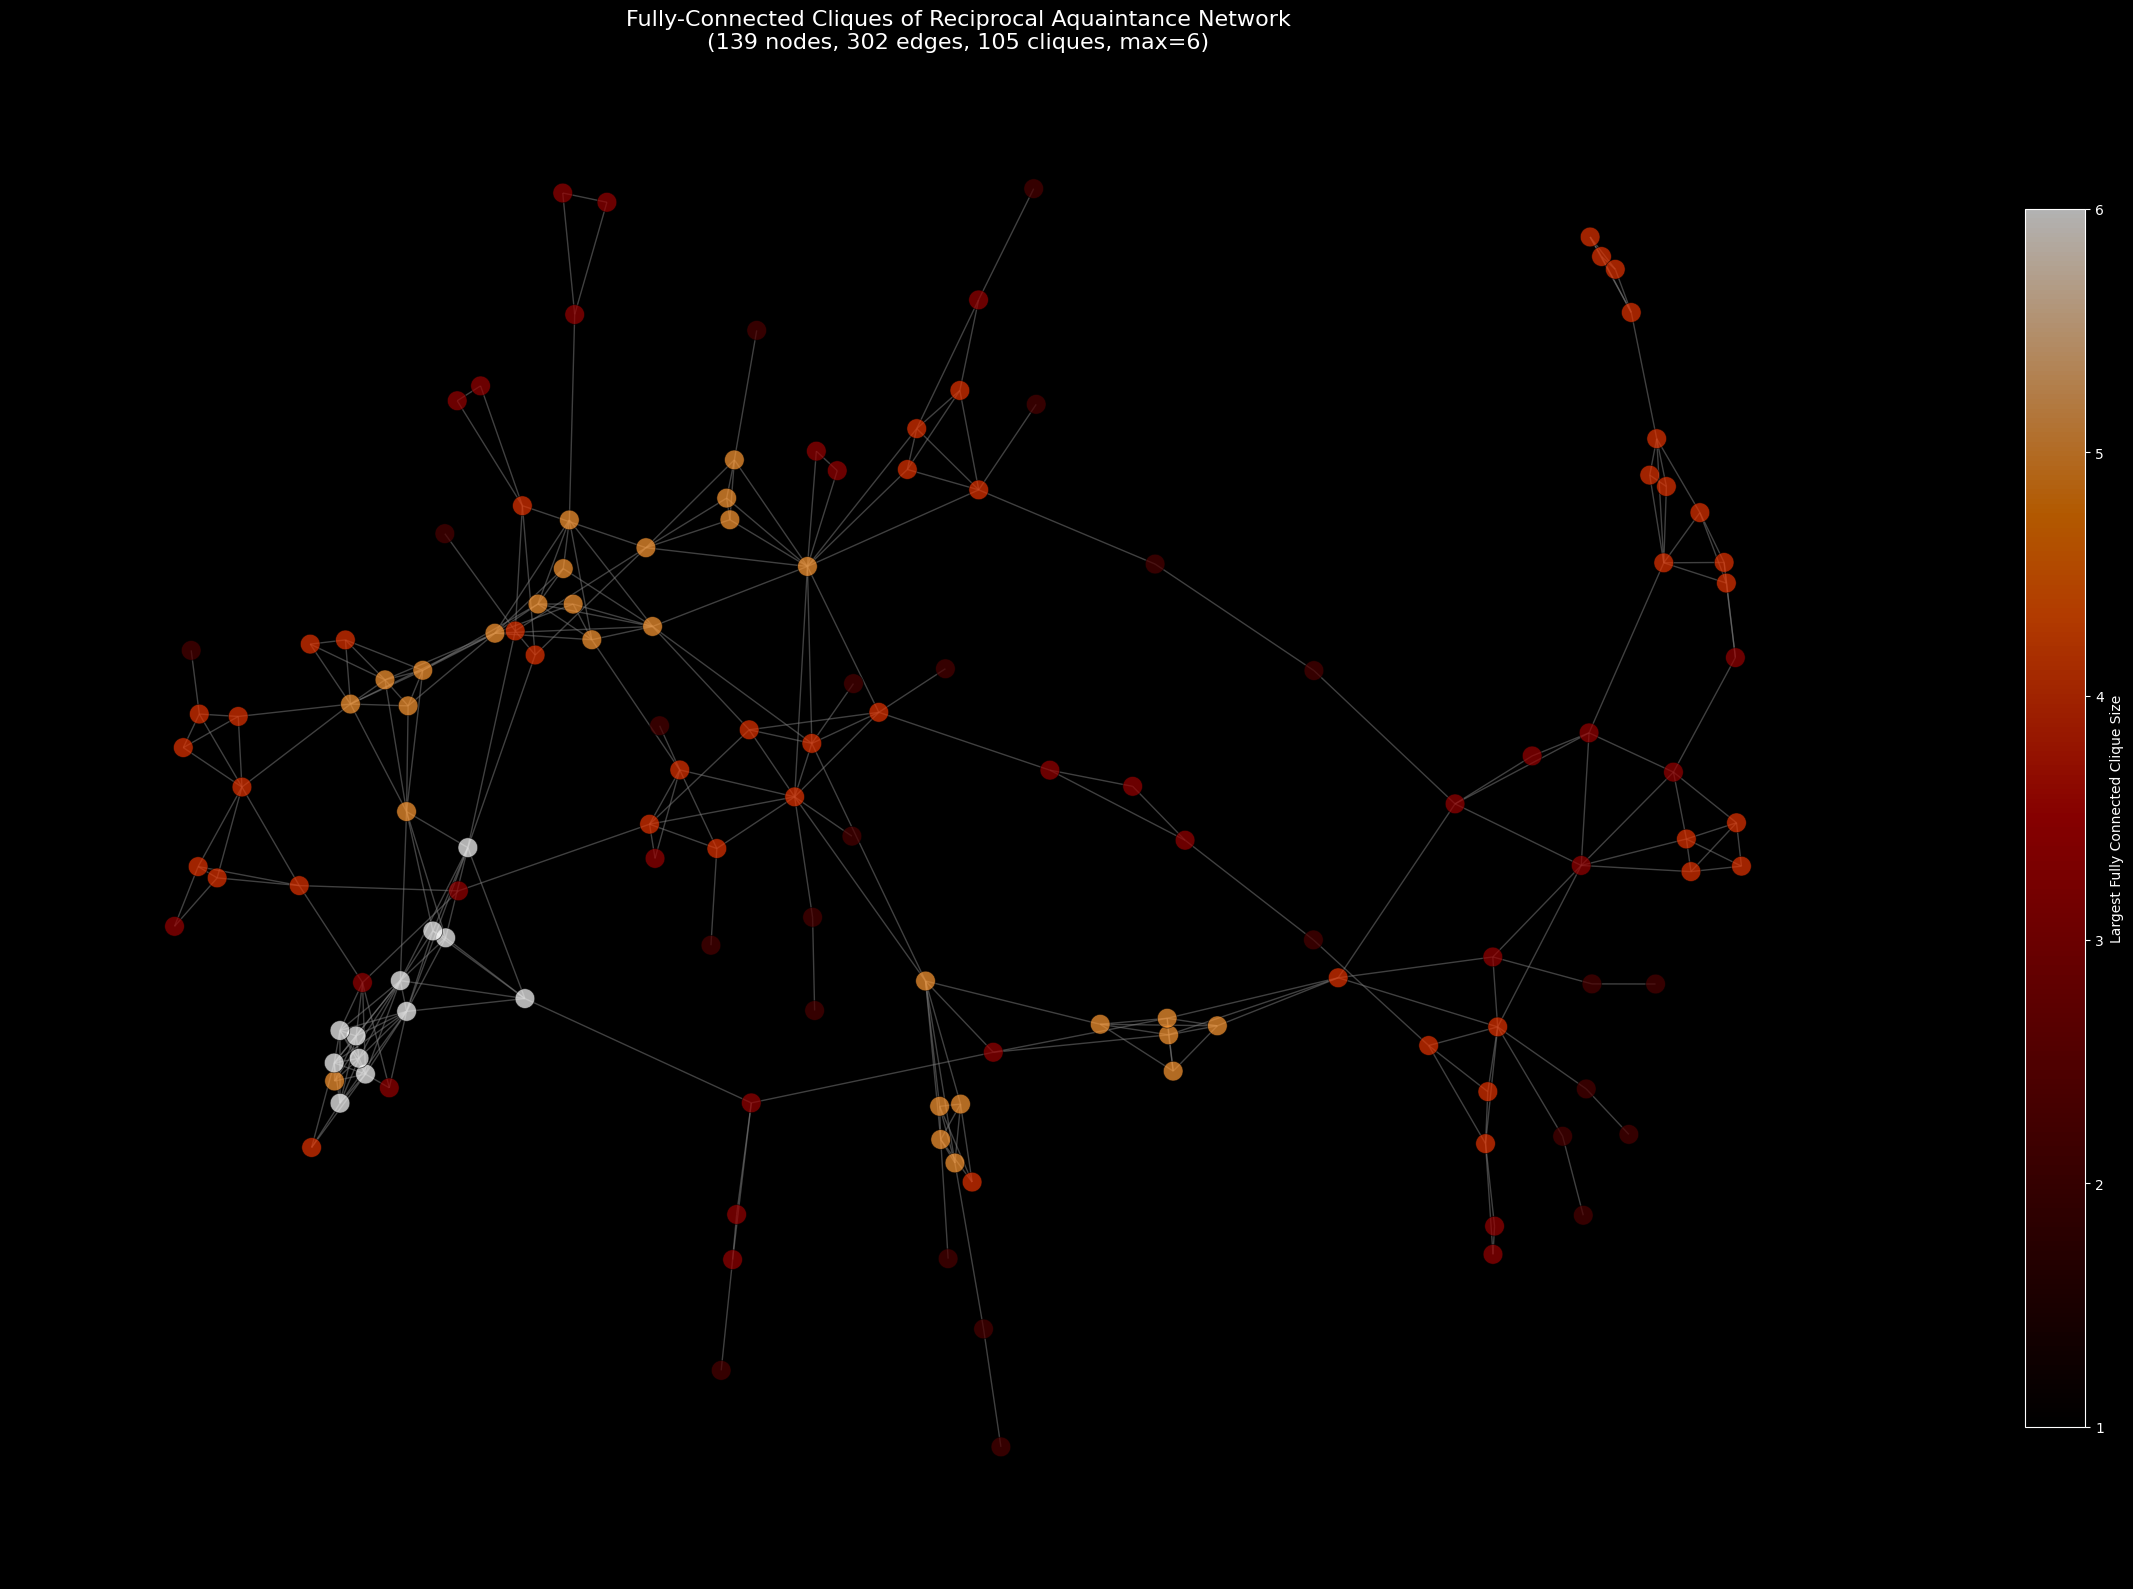


Clique analysis:
Total maximal cliques: 105
Largest clique size: 6
Average clique size: 3.15
Color scale: 1 to 6


In [49]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

# -----------------------------
# FIXED COLOR SCALE
# -----------------------------
CLIQUE_MIN = 1  # Minimum clique size for color scale
CLIQUE_MAX = 6  # Maximum clique size for color scale
# Adjust CLIQUE_MAX based on your domain knowledge

# Convert to undirected (reciprocal edges only)
G_undirected = G_aquaintance.to_undirected(reciprocal=True)

# Filter isolated nodes (optional - uncomment if needed)
isolated_nodes = list(nx.isolates(G_undirected))
G_undirected.remove_nodes_from(isolated_nodes)

# pick largest CC
largest_cc = max(nx.connected_components(G_undirected), key=len)
G_undirected = G_undirected.subgraph(largest_cc).copy()

G_sub = G_undirected.copy()

# Find cliques and calculate node colors
cliques = list(nx.find_cliques(G_sub))
clique_sizes = {}
for node in G_sub.nodes():
    max_size = 0
    for clique in cliques:
        if node in clique:
            max_size = max(max_size, len(clique))
    clique_sizes[node] = max_size

node_colors = [clique_sizes[node] for node in G_sub.nodes()]

# Create figure
plt.figure(figsize=(24, 16))

# Generate layout
from networkx.drawing.nx_agraph import graphviz_layout
pos = graphviz_layout(G_sub, prog='sfdp')

# Draw nodes with FIXED colormap scale
nodes = nx.draw_networkx_nodes(G_sub, pos, node_size=200, 
                                node_color=node_colors, 
                                cmap='gist_heat', alpha=0.7, 
                                linewidths=0.5, edgecolors='black',
                                vmin=CLIQUE_MIN, vmax=CLIQUE_MAX)  # <-- FIXED SCALE

# Draw edges
nx.draw_networkx_edges(G_sub, pos, edge_color='gray', 
                       alpha=0.5, width=1)

# Add colorbar with fixed scale
cbar = plt.colorbar(nodes, label='Largest Fully Connected Clique Size', shrink=0.8)
cbar.set_ticks(range(CLIQUE_MIN, CLIQUE_MAX + 1))
plt.style.use('dark_background')
# Title
actual_max = max(node_colors) if node_colors else 0
plt.title(f"Fully-Connected Cliques of Reciprocal Aquaintance Network\n"
          f"({len(G_sub.nodes())} nodes, {len(G_sub.edges())} edges, "
          f"{len(cliques)} cliques, max={actual_max})", 
          fontsize=16)
plt.axis('off')
plt.tight_layout()
plt.show()

# Print clique information
print(f"\nClique analysis:")
print(f"Total maximal cliques: {len(cliques)}")
clique_sizes_list = [len(c) for c in cliques]
print(f"Largest clique size: {max(clique_sizes_list)}")
print(f"Average clique size: {np.mean(clique_sizes_list):.2f}")
print(f"Color scale: {CLIQUE_MIN} to {CLIQUE_MAX}")

In [50]:
cliques

[['qlq', 'cp4', '95j', '9vw'],
 ['qlq', 'cp4', '7mf'],
 ['qlq', '8fi', 'ol7', 'msn'],
 ['ctx', 'r9o', '5ci'],
 ['r75', '5ci'],
 ['r75', 'c38'],
 ['qip', 'r3x', 'qdi', 'aq6'],
 ['qip', 'r3x', '7w1'],
 ['3ue', 'pfr'],
 ['3ue', 'ier', 'is2'],
 ['3ue', 'ty0'],
 ['hxt', 'joy', 'dq4'],
 ['hxt', 'joy', 'w9x'],
 ['hxt', 'fno', 'dq4', '7y2'],
 ['hxt', 'fno', 'w9x'],
 ['svh', '8yu'],
 ['svh', 'fsu'],
 ['w9x', 'g52', 'j0g'],
 ['w9x', 'g52', 'joy'],
 ['w9x', 'zit', '2g7'],
 ['4w0', '1zx', 'bty', '26o'],
 ['t6m', 'zvr'],
 ['t6m', 'zit'],
 ['yyj', 'ayq', '5sz', '26o', '1uq', 'ej8'],
 ['yyj', 'ayq', '5sz', '26o', '1uq', '1zx'],
 ['yyj', 'ayq', 'wom', 'pfr', '0fo', 'hro'],
 ['yyj', 'jjt', '5sz', '26o', 'ej8'],
 ['yyj', 'jjt', '5sz', '26o', '1zx'],
 ['yyj', 'cav', '0fo', 'wom', 'hro'],
 ['go4', 'vpi', 'ras', 'ljz'],
 ['go4', 'vpi', 'ras', 'fsu', 'poi'],
 ['go4', 'uqn'],
 ['1ds', '1k3'],
 ['5sz', 'bty', 'ayq', '26o', '1uq', 'ej8'],
 ['5sz', 'bty', 'ayq', '26o', '1uq', '1zx'],
 ['3rt', '7mf', 'i9d', '685

We have a ground truth of the frindship network and its groups, we can now compare this to the perception of people of said group in their network. 

Find out if there is a difference between perceived groups and "ground-truth" / construct for friendship groups. 

What is the distribution of deviation in perceptions from the metric obtained by the network. 

Interesting is that each group is viewed from a multitude of viewpoints from members of said group.

Q: Do people correlate more with reciprocal or one way groups.


Friend graph components:
  Component 0: 89 nodes
  Component 1: 35 nodes
  Component 2: 4 nodes
  Component 3: 3 nodes
  Component 4: 3 nodes

Edge breakdown:
  Friendship edges: 234
  Acquaintance-only edges: 331
  Total edges: 565


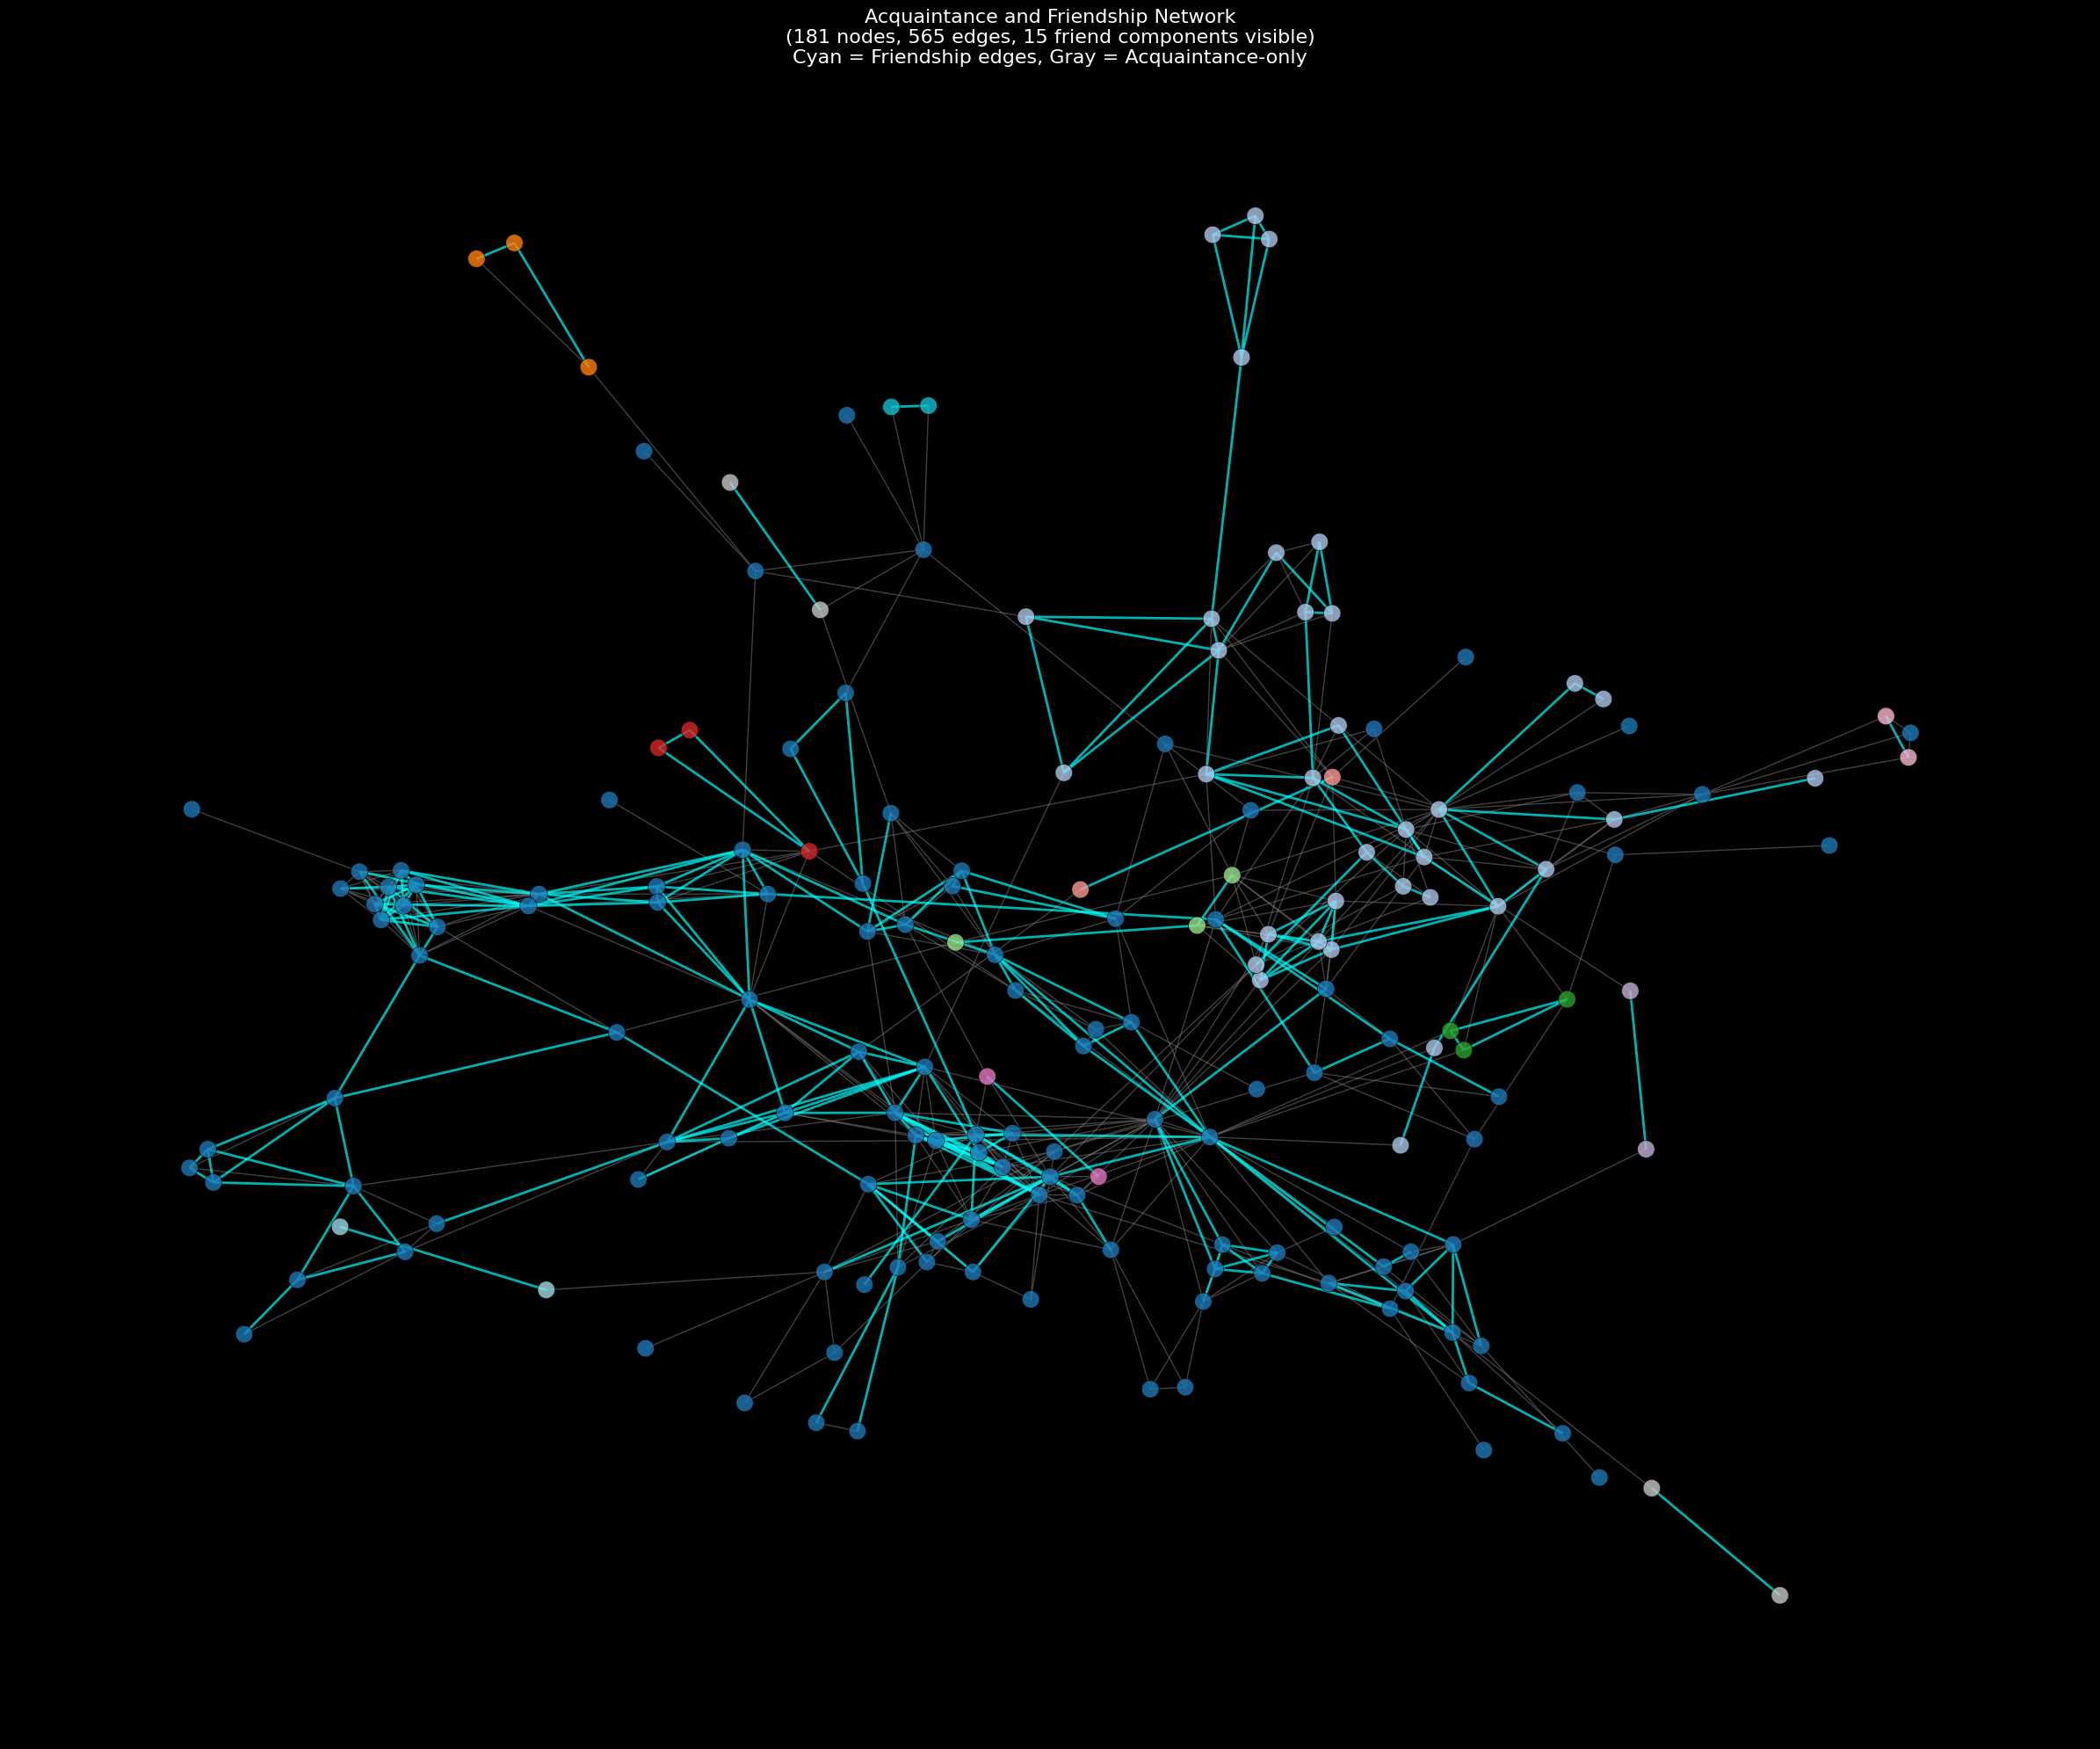


Visualization stats:
Nodes in acquaintance graph: 181
Nodes that exist in friend graph: 152
Nodes only in acquaintance graph: 29
Friend components represented: 15


In [51]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

# -----------------------------
# STEP 1: Find components in FRIEND graph
# -----------------------------
G_friend_undirected = G_friend.to_undirected(reciprocal=True)

# Remove isolated nodes
isolated_nodes = list(nx.isolates(G_friend_undirected))
G_friend_undirected.remove_nodes_from(isolated_nodes)

# Get all connected components sorted by size
friend_components = sorted(nx.connected_components(G_friend_undirected), key=len, reverse=True)

# Mark each node with its component ID
component_map = {}
for i, component in enumerate(friend_components):
    for node in component:
        component_map[node] = i

print(f"\nFriend graph components:")
for i, comp in enumerate(friend_components[:5]):  # Show top 5
    print(f"  Component {i}: {len(comp)} nodes")

# -----------------------------
# STEP 2: Prepare ACQUAINTANCE graph
# -----------------------------
G_undirected = G_aquaintance.to_undirected(reciprocal=False)
isolated_nodes = list(nx.isolates(G_undirected))
G_undirected.remove_nodes_from(isolated_nodes)

# Get largest component of acquaintance graph for visualization
largest_cc = max(nx.connected_components(G_undirected), key=len)
G_sub = G_undirected.subgraph(largest_cc).copy()

# Transfer component labels from friend graph to acquaintance graph
nx.set_node_attributes(G_sub, -1, 'friend_component')
for node in G_sub.nodes():
    if node in component_map:
        G_sub.nodes[node]['friend_component'] = component_map[node]

# Generate layout
from networkx.drawing.nx_agraph import graphviz_layout
pos = graphviz_layout(G_sub, prog='sfdp')

# -----------------------------
# STEP 3: Separate edges into friendship vs acquaintance-only
# -----------------------------
friend_edges = []
acquaintance_only_edges = []

for edge in G_sub.edges():
    if G_friend_undirected.has_edge(edge[0], edge[1]):
        friend_edges.append(edge)
    else:
        acquaintance_only_edges.append(edge)

print(f"\nEdge breakdown:")
print(f"  Friendship edges: {len(friend_edges)}")
print(f"  Acquaintance-only edges: {len(acquaintance_only_edges)}")
print(f"  Total edges: {len(G_sub.edges())}")

# -----------------------------
# STEP 4: Visualize with highlighted friendships
# -----------------------------
plt.figure(figsize=(24, 20))

# Get component colors
component_colors = [G_sub.nodes[node]['friend_component'] for node in G_sub.nodes()]

# Draw acquaintance-only edges FIRST (background, faded)
nx.draw_networkx_edges(G_sub, pos, edgelist=acquaintance_only_edges,
                        edge_color='gray', alpha=0.5, width=1.)

# Draw friendship edges ON TOP (highlighted, bright)
nx.draw_networkx_edges(G_sub, pos, edgelist=friend_edges,
                        edge_color='cyan', alpha=0.7, width=2.0)

# Draw nodes last (on top of edges)
nodes = nx.draw_networkx_nodes(G_sub, pos, node_size=200,
                                node_color=component_colors,
                                cmap='tab20', alpha=0.8,
                                linewidths=0.5, edgecolors='black')

plt.style.use('dark_background')

# Count how many friend components are visible
visible_components = len(set(component_colors))
plt.title(f"Acquaintance and Friendship Network\n"
          f"({len(G_sub.nodes())} nodes, {len(G_sub.edges())} edges, "
          f"{visible_components} friend components visible)\n"
          f"Cyan = Friendship edges, Gray = Acquaintance-only", 
          fontsize=16)
plt.axis('off')
plt.tight_layout()
plt.show()

# Print stats
nodes_with_friend_component = sum(1 for c in component_colors if c >= 0)
print(f"\nVisualization stats:")
print(f"Nodes in acquaintance graph: {len(G_sub.nodes())}")
print(f"Nodes that exist in friend graph: {nodes_with_friend_component}")
print(f"Nodes only in acquaintance graph: {len(G_sub.nodes()) - nodes_with_friend_component}")
print(f"Friend components represented: {visible_components}")

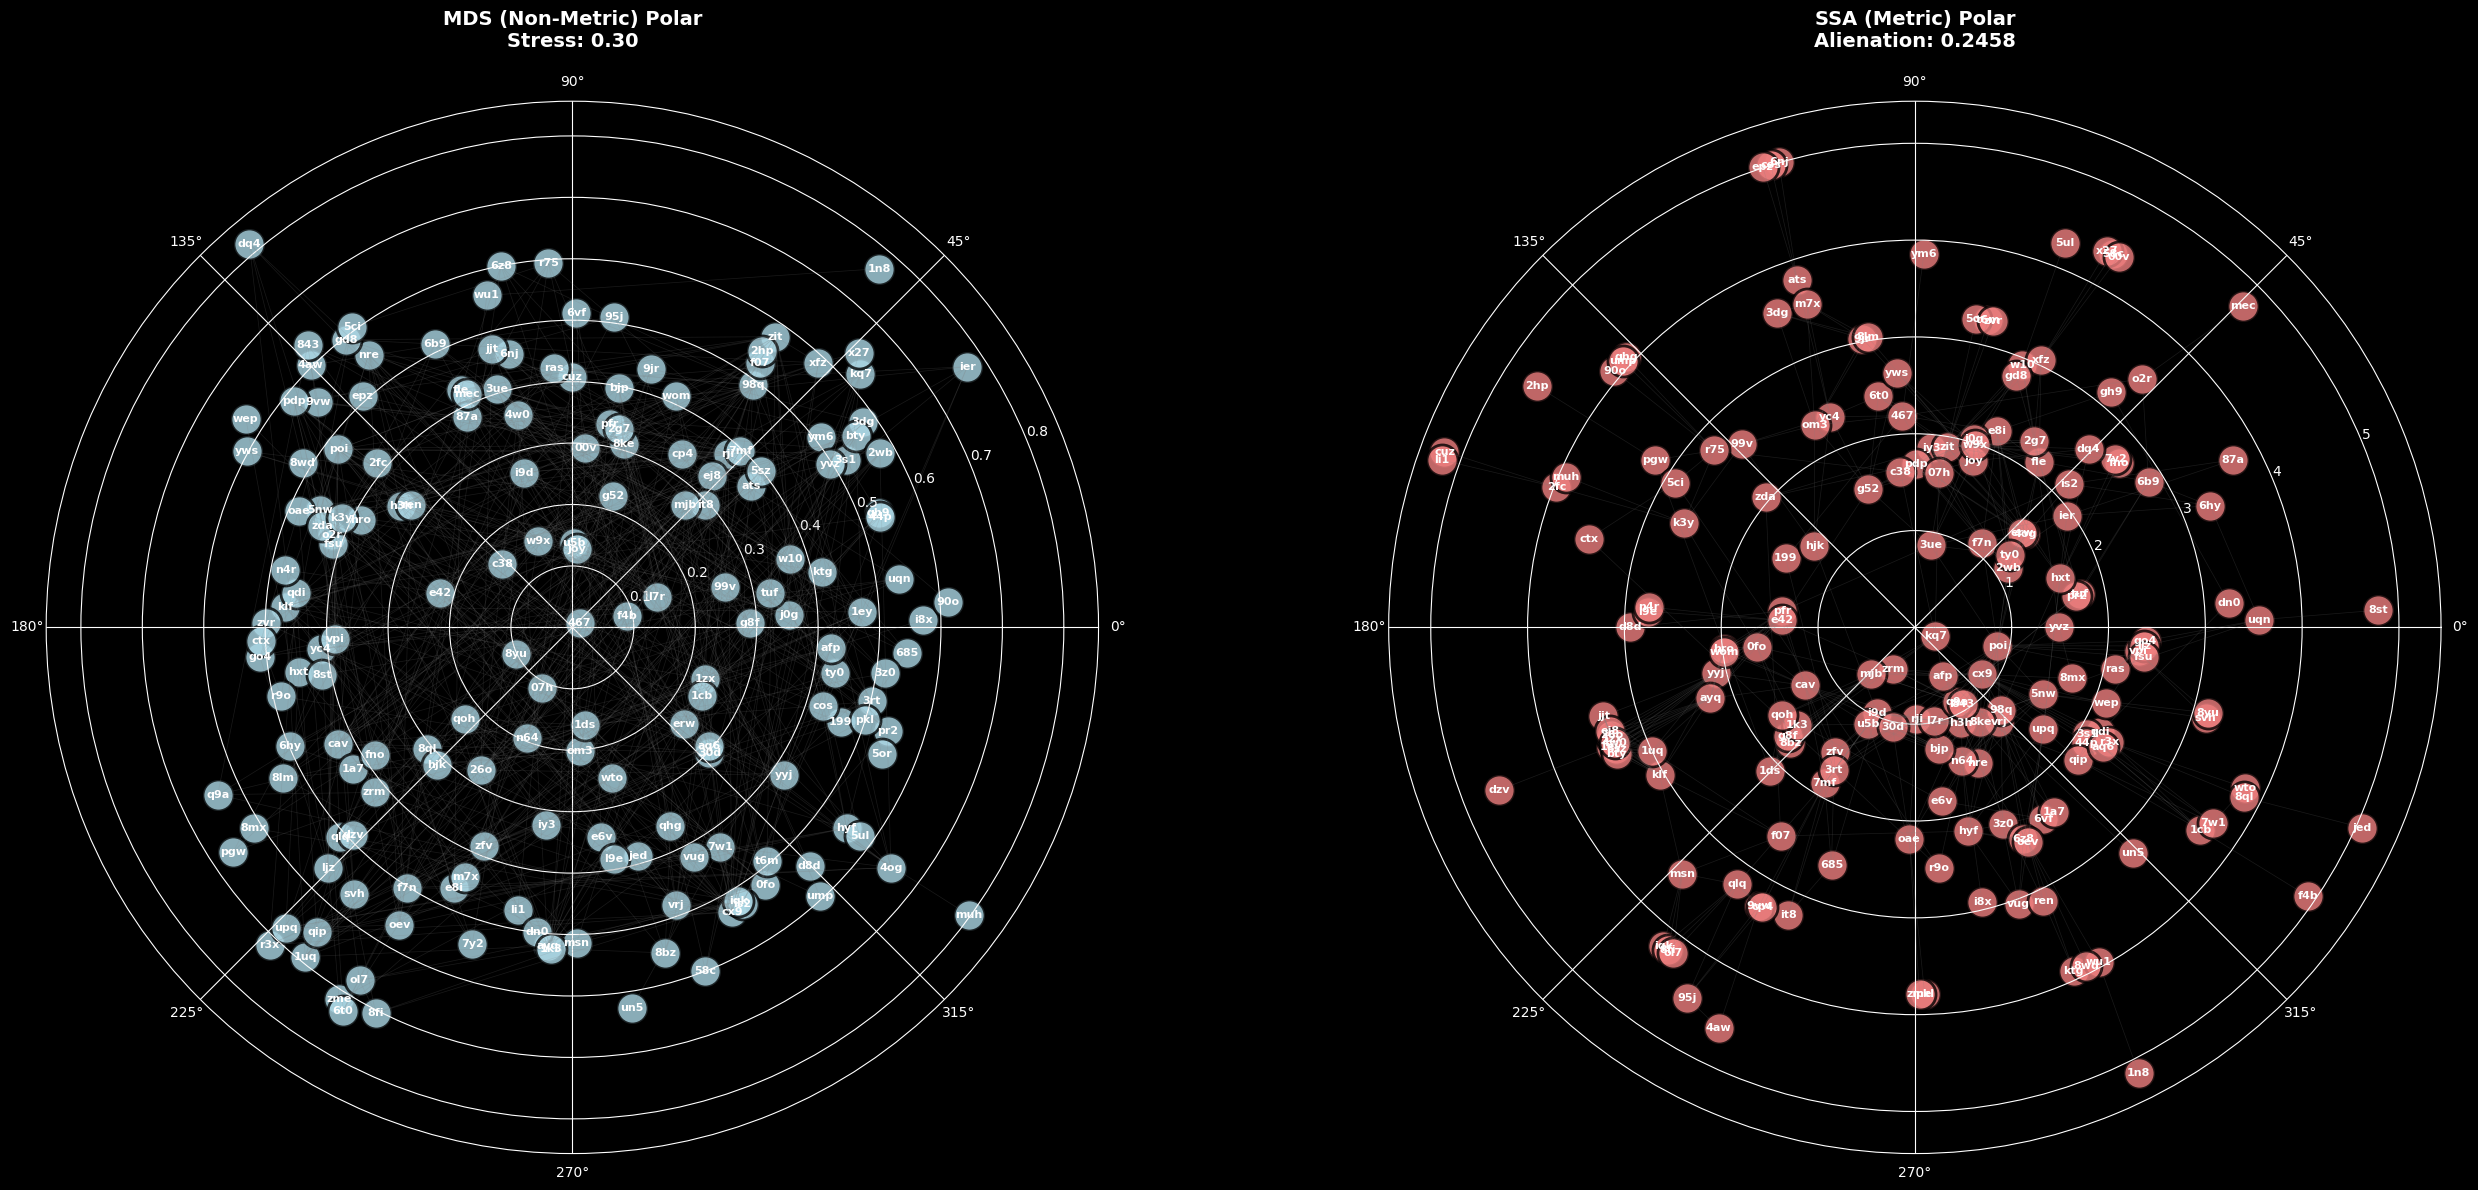

Nodes: 181

MDS Stress: 0.30
SSA Alienation: 0.2458 (< 0.15 = excellent, < 0.20 = good, < 0.25 = acceptable)


In [53]:
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.manifold import MDS
import numpy as np

G_friend_undirected = G_aquaintance.to_undirected(reciprocal=False)
largest_cc = max(nx.connected_components(G_friend_undirected), key=len)
G_largest = G_friend_undirected.subgraph(largest_cc).copy()

nodes = list(G_largest.nodes())
n = len(nodes)

# Distance matrix
dist_matrix = np.zeros((n, n))
for i, node_i in enumerate(nodes):
    for j, node_j in enumerate(nodes):
        if i != j:
            dist_matrix[i][j] = nx.shortest_path_length(G_largest, node_i, node_j)

# Ensure symmetry
dist_matrix = (dist_matrix + dist_matrix.T) / 2

# ===== MDS (non-metric) =====
mds = MDS(n_components=2, dissimilarity='precomputed', 
          metric=False, random_state=42)
coords_mds = mds.fit_transform(dist_matrix)
r_mds = np.sqrt(coords_mds[:, 0]**2 + coords_mds[:, 1]**2)
theta_mds = np.arctan2(coords_mds[:, 1], coords_mds[:, 0])

# ===== SSA (metric) =====
ssa = MDS(n_components=2, dissimilarity='precomputed', 
          metric=True, random_state=42, max_iter=1000, eps=1e-9)
coords_ssa = ssa.fit_transform(dist_matrix)
r_ssa = np.sqrt(coords_ssa[:, 0]**2 + coords_ssa[:, 1]**2)
theta_ssa = np.arctan2(coords_ssa[:, 1], coords_ssa[:, 0])

# Compute alienation for SSA
fitted_dists_ssa = np.sqrt(((coords_ssa[:, np.newaxis, :] - coords_ssa[np.newaxis, :, :]) ** 2).sum(axis=2))
original_dists = dist_matrix.copy()
np.fill_diagonal(original_dists, 0)
np.fill_diagonal(fitted_dists_ssa, 0)

mask = original_dists > 0
alienation = np.sqrt(np.sum((original_dists[mask] - fitted_dists_ssa[mask])**2) / 
                     np.sum(original_dists[mask]**2))

# ===== VISUALIZE BOTH IN POLAR =====
fig = plt.figure(figsize=(27, 12))
ax1 = fig.add_subplot(121, projection='polar')
ax2 = fig.add_subplot(122, projection='polar')

# MDS Polar
for edge in G_largest.edges():
    i = nodes.index(edge[0])
    j = nodes.index(edge[1])
    ax1.plot([theta_mds[i], theta_mds[j]], [r_mds[i], r_mds[j]], 
             'gray', alpha=0.2, linewidth=0.5)

ax1.scatter(theta_mds, r_mds, s=500, c='lightblue', 
            edgecolors='black', linewidth=2, alpha=0.8)

for i, node in enumerate(nodes):
    ax1.text(theta_mds[i], r_mds[i], str(node), 
             ha='center', va='center', fontsize=8, weight='bold')

ax1.set_title(f'MDS (Non-Metric) Polar\nStress: {mds.stress_:.2f}', 
              fontsize=14, weight='bold', pad=20)

# SSA Polar
for edge in G_largest.edges():
    i = nodes.index(edge[0])
    j = nodes.index(edge[1])
    ax2.plot([theta_ssa[i], theta_ssa[j]], [r_ssa[i], r_ssa[j]], 
             'gray', alpha=0.2, linewidth=0.5)

ax2.scatter(theta_ssa, r_ssa, s=500, c='lightcoral', 
            edgecolors='black', linewidth=2, alpha=0.8)

for i, node in enumerate(nodes):
    ax2.text(theta_ssa[i], r_ssa[i], str(node), 
             ha='center', va='center', fontsize=8, weight='bold')

ax2.set_title(f'SSA (Metric) Polar\nAlienation: {alienation:.4f}', 
              fontsize=14, weight='bold', pad=20)

plt.tight_layout()
plt.show()

print(f"Nodes: {n}")
print(f"\nMDS Stress: {mds.stress_:.2f}")
print(f"SSA Alienation: {alienation:.4f} (< 0.15 = excellent, < 0.20 = good, < 0.25 = acceptable)")

Text(0.5, 1.0, 'Original Graph Embedding')

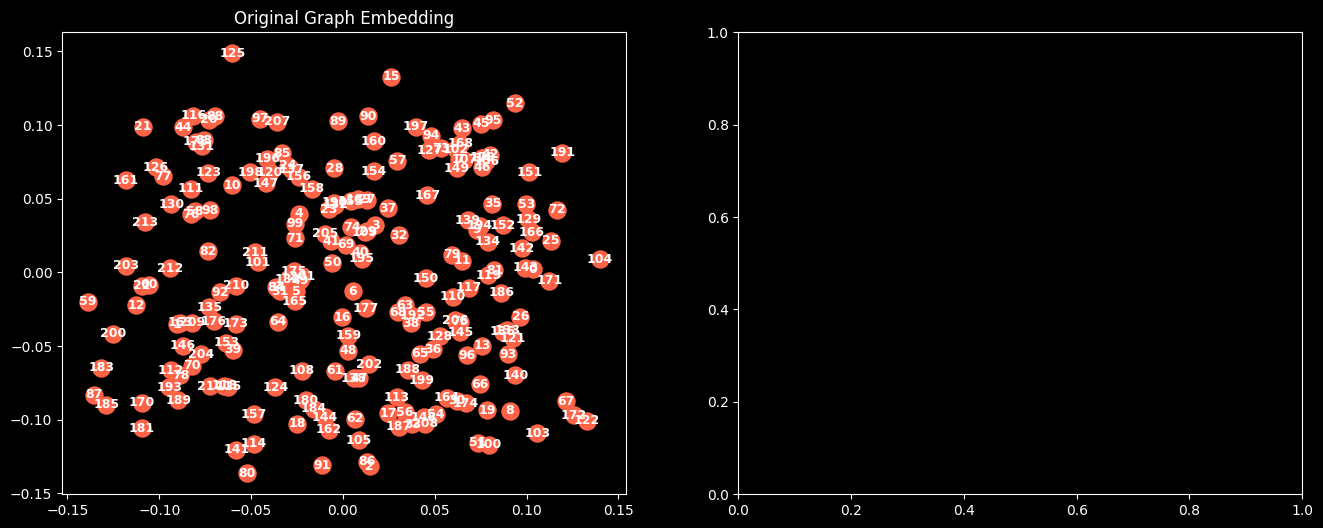

In [64]:
import numpy as np
from scipy.linalg import fractional_matrix_power
from scipy.sparse.linalg import eigsh  # for symmetric matrices

G_friend_undirected = G_study.to_undirected(reciprocal=False)
largest_cc = max(nx.connected_components(G_friend_undirected), key=len)
G_largest = G_friend_undirected.subgraph(largest_cc).copy()

# spectral node embedding for graph
A = nx.to_numpy_array(G_friend)
np.fill_diagonal(A, 0)

# Degree matrix
D = np.diag(A.sum(axis=1))

# Unnormalized Laplacian
L = D - A

# Optional: normalized Laplacian
D_inv_sqrt = fractional_matrix_power(D, -0.5)
L_norm = D_inv_sqrt @ L @ D_inv_sqrt

# Compute k smallest eigenvalues/vectors (skip the trivial zero eigenvector)
k = 2  # embedding dimension
eigvals, eigvecs = eigsh(L_norm, k=k+1, which='SM')  # smallest magnitude
embedding_orig = eigvecs[:, 1:k+1]  # skip the first (constant) eigenvector

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Original
axes[0].scatter(embedding_orig[:, 0], embedding_orig[:, 1], s=150, c='tomato')
for i, (x, y) in enumerate(embedding_orig):
    axes[0].text(x, y, str(i), fontsize=9, ha='center', va='center', color='white', weight='bold')
axes[0].set_title("Original Graph Embedding")